# Descriptive Statistics + Exploratory Analysis



---



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set a global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

In [6]:
# Load Data
ret_raw   = pd.read_csv('All_Retention.csv')
media_all = pd.read_csv('All_Media_No_Empty.csv')
digital   = pd.read_csv('Digital_Media_Only.csv')

# Clean retention
num_cols = [c for c in ret_raw.columns if c not in ('State', 'Grade', 'Academic Year')]
for col in num_cols:
    ret_raw[col] = pd.to_numeric(
        ret_raw[col].astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )

# Filter to grades 8, 10, 12 only
# Ignore national aggregate row
ret = ret_raw[
  ret_raw['Grade'].astype(str).isin(['8', '10', '12']) &
  (ret_raw['State'] != 'United States')
].copy()

print(f'Retention rows (grades 8,10,12, state-level): {len(ret):,}')
print(f'Media rows: {len(media_all):,}  |  Digital rows: {len(digital):,}')
ret.head(3)


Retention rows (grades 8,10,12, state-level): 465
Media rows: 286  |  Digital rows: 128


,State,Total Students,Number_Male,Percent_Male,Number_Female,Percent_Female,Number_American Indian or Alaska Native,Percent_American Indian or\nAlaska Native,Number_Asian,Percent_Asian,...,Number_Students With Disabilities Served Under IDEA,Percent_Students With Disabilities Served Under IDEA,Number_Students With Disabilities Served Only Under Section 504,Percent_Students With Disabilities Served Only Under Section 504,Number_English Language Learners,Percent_English Language Learners,Number of Schools,Percent of Schools Reporting,Grade,Academic Year
53,Alabama,3230.0,2014.0,0.62,1216.0,0.38,22.0,0.7,14.0,0.4,...,400.0,12.4,39.0,1.2,75.0,2.3,236.0,100.0,10,2013-2014
54,Alaska,79.0,35.0,0.44,44.0,0.56,68.0,86.1,0.0,0.0,...,6.0,7.6,0.0,0.0,28.0,35.4,48.0,100.0,10,2013-2014
55,Arizona,3419.0,2023.0,0.59,1396.0,0.41,171.0,5.0,38.0,1.1,...,453.0,13.2,39.0,1.1,210.0,6.1,69.0,100.0,10,2013-2014




---



**Descriptive Statistics**


Retention Data:

In [7]:
ts = ret['Total Students'].dropna()

desc = pd.Series({
    'N (observations)': len(ts),
    'Mean':             ts.mean(),
    'Median':           ts.median(),
    'Std Dev':          ts.std(),
    'Min':              ts.min(),
    'Max':              ts.max(),
    'Skewness':         ts.skew(),
    'Kurtosis':         ts.kurt(),
}).rename('Retained Students per State-Grade-Year')

print('=== Total Retained Students — Summary ===')
print(desc.apply(lambda x: f'{x:,.2f}' if isinstance(x, float) else f'{x:,}').to_string())

=== Total Retained Students — Summary ===
N (observations)        465.00
Mean                  2,567.98
Median                  748.00
Std Dev               9,127.57
Min                       6.00
Max                 137,998.00
Skewness                 12.57
Kurtosis                176.70


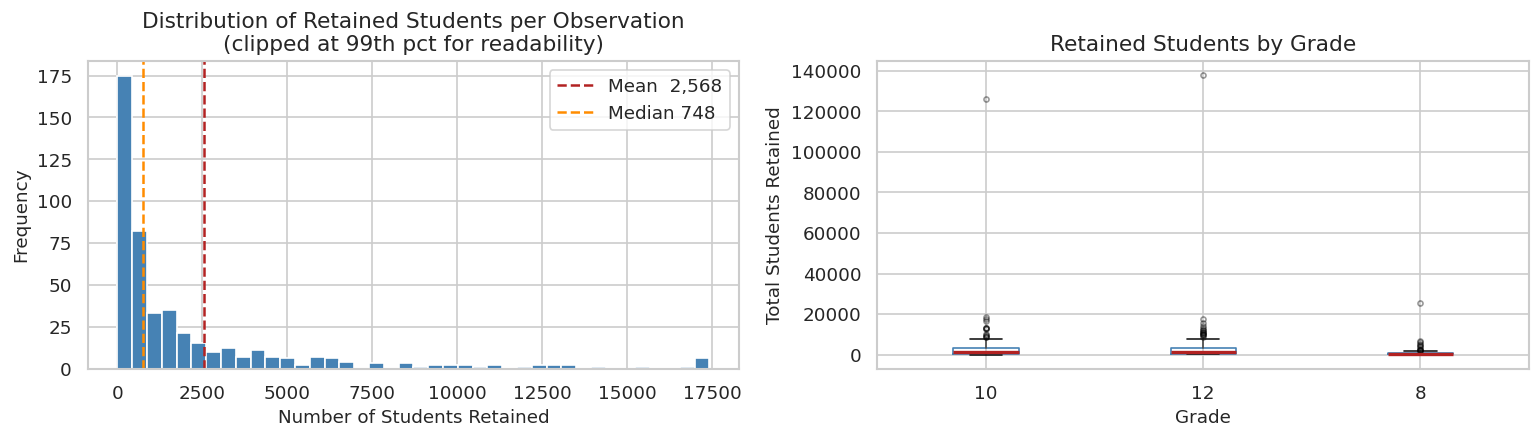

Note: Heavy right skew (skewness ≈ 12.57) driven by large-enrollment states (CA, TX, NY).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(ts.clip(upper=ts.quantile(0.99)), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(ts.mean(),   color='firebrick', linestyle='--', label=f'Mean  {ts.mean():,.0f}')
axes[0].axvline(ts.median(), color='darkorange', linestyle='--', label=f'Median {ts.median():,.0f}')
axes[0].set_title('Distribution of Retained Students per Observation\n(clipped at 99th pct for readability)')
axes[0].set_xlabel('Number of Students Retained')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box-plot by grade
ret.boxplot(column='Total Students', by='Grade', ax=axes[1],
            boxprops=dict(color='steelblue'),
            medianprops=dict(color='firebrick', linewidth=2),
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
axes[1].set_title('Retained Students by Grade')
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Total Students Retained')
plt.suptitle('')

plt.tight_layout()
plt.savefig('fig_retention_dist.png', bbox_inches='tight')
plt.show()
print('Note: Heavy right skew (skewness ≈ 12.57) driven by large-enrollment states (CA, TX, NY).')

=== Gender Share of Retained Students ===
            mean     std   min   50%   max
Male %    0.6214  0.0557  0.14  0.62  0.88
Female %  0.3759  0.0563  0.13  0.38  0.86


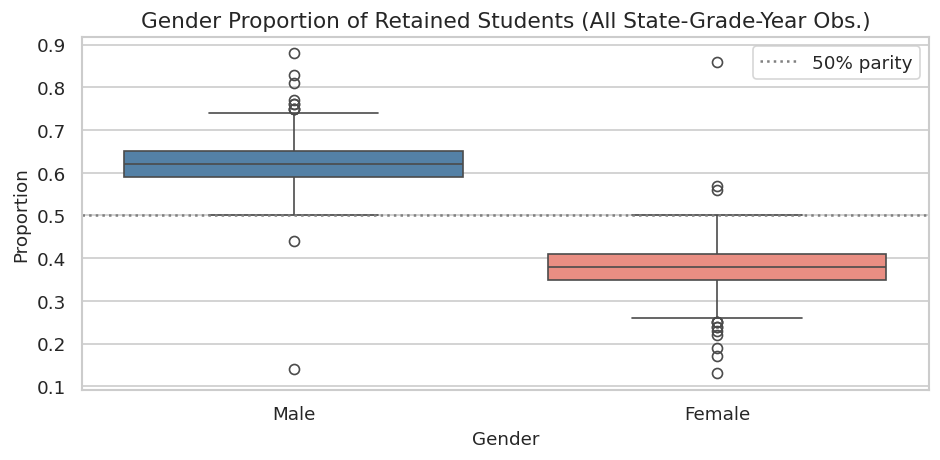

Male students are consistently over-represented among retained students (~62% on average).


In [10]:
# Breakdown by Gender
gender_stats = ret[['Percent_Male', 'Percent_Female']].describe().T
gender_stats.index = ['Male %', 'Female %']
print('=== Gender Share of Retained Students ===')
print(gender_stats[['mean','std','min','50%','max']].round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ret[['Percent_Male', 'Percent_Female']].rename(columns={'Percent_Male':'Male', 'Percent_Female':'Female'}) \
    .melt(var_name='Gender', value_name='Proportion') \
    .pipe(lambda d: sns.boxplot(data=d, x='Gender', y='Proportion', palette=['steelblue','salmon'], ax=ax))
ax.axhline(0.5, color='gray', linestyle=':', label='50% parity')
ax.set_title('Gender Proportion of Retained Students (All State-Grade-Year Obs.)')
ax.set_ylabel('Proportion')
ax.legend()
plt.tight_layout()
plt.savefig('fig_gender.png', bbox_inches='tight')
plt.show()
print('Male students are consistently over-represented among retained students (~62% on average).')

=== Racial/Ethnic Share of Retained Students ===
                                    Mean %  Std Dev  Median %
White                               43.872   21.463      42.2
Black/African\nAmerican             23.856   20.354      19.8
Hispanic/\nLatino                   20.903   18.154      16.0
Asian                                2.265    3.360       1.4
Am. Indian/\nAlaska Native           4.783   12.243       0.7
Native Hawaiian/\nPacific Islander   1.344    7.375       0.1
Two or More\nRaces                   3.020    2.472       2.6


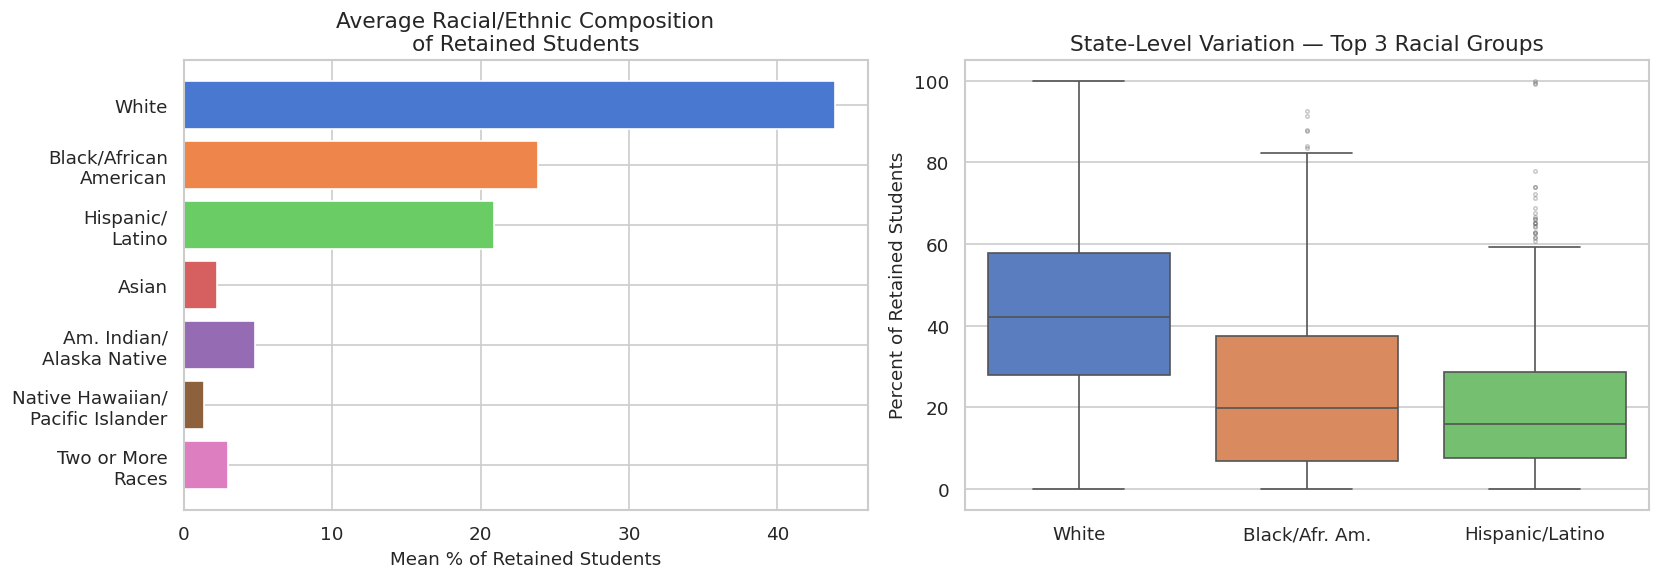

High standard deviations reflect substantial state-to-state variation in racial composition.


In [14]:
# Breakdown by Ethnicity
pct_race_cols = ['Percent_White', 'Percent_Black or African American', 'Percent_Hispanic or Latino of any race', 'Percent_Asian',
                 'Percent_American Indian or\nAlaska Native', 'Percent_Native Hawaiian or Other Pacific Islander', 'Percent_Two or more races']
race_labels   = ['White', 'Black/African\nAmerican', 'Hispanic/\nLatino',
                 'Asian', 'Am. Indian/\nAlaska Native', 'Native Hawaiian/\nPacific Islander', 'Two or More\nRaces']

race_stats = ret[pct_race_cols].describe().T[['mean','std','50%']]
race_stats.index = race_labels
race_stats.columns = ['Mean %', 'Std Dev', 'Median %']
print('=== Racial/Ethnic Share of Retained Students ===')
print(race_stats.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean bar chart
colors = sns.color_palette('muted', len(race_labels))
axes[0].barh(race_labels, race_stats['Mean %'], color=colors, edgecolor='white')
axes[0].set_xlabel('Mean % of Retained Students')
axes[0].set_title('Average Racial/Ethnic Composition\nof Retained Students')
axes[0].invert_yaxis()

# Box plot — top 3 groups for readability
top3 = ['Percent_White', 'Percent_Black or African American', 'Percent_Hispanic or Latino of any race']
top3_labels = ['White', 'Black/Afr. Am.', 'Hispanic/Latino']
melt = ret[top3].rename(columns=dict(zip(top3, top3_labels))).melt(var_name='Group', value_name='Pct')
sns.boxplot(data=melt, x='Group', y='Pct', palette='muted', ax=axes[1],
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_title('State-Level Variation — Top 3 Racial Groups')
axes[1].set_ylabel('Percent of Retained Students')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('fig_ethnicity_desc.png', bbox_inches='tight')
plt.show()
print('High standard deviations reflect substantial state-to-state variation in racial composition.')

=== Special Populations ===
                           Mean %  Std Dev  Median %
IDEA (Disabilities)        25.483   12.648      22.3
Section 504                 3.086    2.658       2.4
English Language Learners   8.850    7.559       7.0


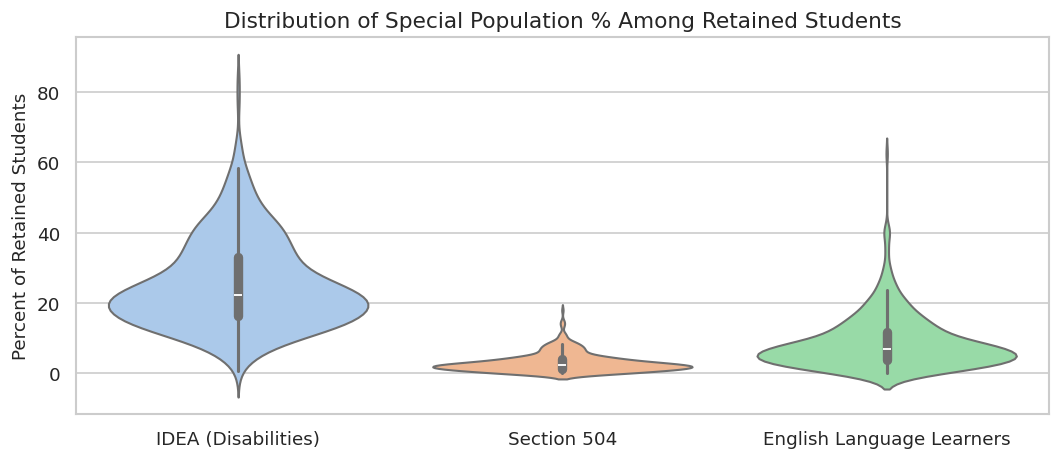

IDEA students are the largest special population (~25.5% on avg). ELL shows high variation tied to state demographics.


In [16]:
# Breakdown by Special Populations
sp_cols   = ['Percent_Students With Disabilities Served Under IDEA', 'Percent_Students With Disabilities Served Only Under Section 504', 'Percent_English Language Learners']
sp_labels = ['IDEA (Disabilities)', 'Section 504', 'English Language Learners']

sp_stats = ret[sp_cols].describe().T[['mean','std','50%']]
sp_stats.index = sp_labels
sp_stats.columns = ['Mean %', 'Std Dev', 'Median %']
print('=== Special Populations ===')
print(sp_stats.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
melt_sp = ret[sp_cols].rename(columns=dict(zip(sp_cols, sp_labels))).melt(var_name='Population', value_name='Pct')
sns.violinplot(data=melt_sp, x='Population', y='Pct', palette='pastel', inner='box', ax=ax)
ax.set_title('Distribution of Special Population % Among Retained Students')
ax.set_ylabel('Percent of Retained Students')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('fig_special_pop.png', bbox_inches='tight')
plt.show()
print('IDEA students are the largest special population (~25.5% on avg). ELL shows high variation tied to state demographics.')

=== Observations with |z| > 2 per Variable ===
Hispanic or Latino of any race                  27
White                                           24
English Language Learners                       20
Students With Disabilities Served Under IDEA    20
Female                                          18
Black or African American                       18
Male                                            16
Asian                                           14


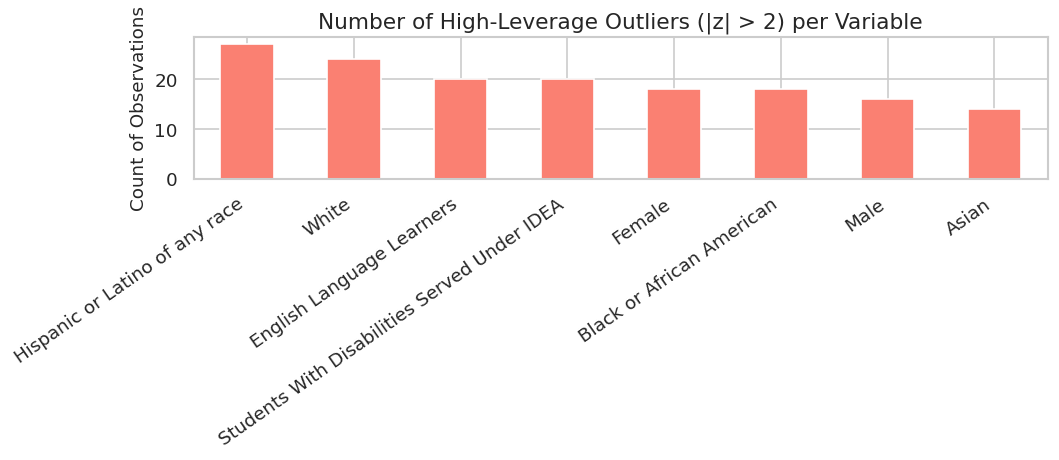

ELL% and Hispanic% have the most high-leverage outliers — consistent with CA, TX, and NY being demographic outliers nationally.


In [20]:
# Z-Score to Detect Outliers
pct_cols_check = ['Percent_White', 'Percent_Black or African American', 'Percent_Hispanic or Latino of any race', 'Percent_Asian',
                 'Percent_Students With Disabilities Served Under IDEA', 'Percent_English Language Learners', 'Percent_Male', 'Percent_Female']

z_df = ret[pct_cols_check].apply(stats.zscore, nan_policy='omit')
z_df.columns = [c.replace('Percent_', '') for c in pct_cols_check]

outlier_counts = (z_df.abs() > 2).sum().sort_values(ascending=False)
print('=== Observations with |z| > 2 per Variable ===')
print(outlier_counts.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
outlier_counts.plot(kind='bar', color='salmon', edgecolor='white', ax=ax)
ax.set_title('Number of High-Leverage Outliers (|z| > 2) per Variable')
ax.set_ylabel('Count of Observations')
ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('fig_outliers.png', bbox_inches='tight')
plt.show()
print('ELL% and Hispanic% have the most high-leverage outliers — consistent with CA, TX, and NY being demographic outliers nationally.')



---

Media Use:

In [23]:
# Seperate means and percents
means_df   = media_all[media_all['value_mean_or_percent'] == 'mean'].copy()
percent_df = media_all[media_all['value_mean_or_percent'] == 'percent'].copy()

print('Unique subcategories (means):', means_df['Subcategory'].unique())
print('\nUnique subcategories (percents):', percent_df['Subcategory'].unique())

# Overall descriptive stats by subcategory
overall = media_all.groupby(['Category', 'Subcategory', 'value_mean_or_percent'])['value'].describe()[['mean','std','min','max']]
print('\n=== Media Use — Overall Descriptive Stats ===')
print(overall.round(3).to_string())

Unique subcategories (means): ['Internet(hr/day)' 'Texting (hr/day)' 'Social Media (hr/day)'
 'Social Media (1-5 scale)' 'Gaming(hr/day)' 'Books (# in last year)'
 'books/magazines (1-5 scale)' 'Magazines(1-5 scale)'
 'Newspapers(1-5 scale)' 'Going to movies(1-5 scale)'
 'TV (hr/day) (weekdays only)' 'TV (hr/day)']

Unique subcategories (percents): ['Social Media almost every day (%)' 'books/magazines every day (%)']

=== Media Use — Overall Descriptive Stats ===
                                                                         mean     std    min    max
Category      Subcategory                       value_mean_or_percent                              
Digital Media Gaming(hr/day)                    mean                    1.369   0.197   0.92   1.62
              Internet(hr/day)                  mean                    1.494   0.338   1.04   2.18
              Social Media (1-5 scale)          mean                    4.330   0.245   3.73   4.65
              Social Media (hr/d

=== Mean Internet Use (hr/day) by Year Period ===
     year    value
2005-2009 1.073333
     2010 1.203333
     2011 1.266667
     2012 1.353333
     2013 1.566667
     2014 1.746667
     2015 1.823333
     2016 1.920000


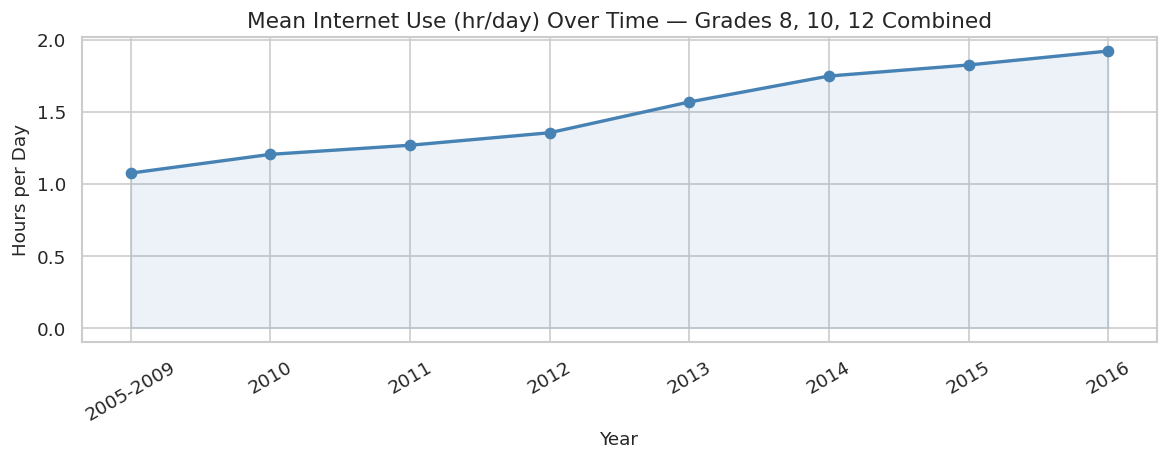

Internet use nearly doubled from ~1.07 hr/day (2005-2009) to ~1.92 hr/day by 2016.


In [24]:
# Internet Use Over Time
internet = digital[digital['Subcategory'] == 'Internet(hr/day)'].copy()
internet_yr = internet.groupby('year')['value'].mean().reset_index()

print('=== Mean Internet Use (hr/day) by Year Period ===')
print(internet_yr.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(internet_yr['year'], internet_yr['value'], marker='o', color='steelblue', linewidth=2)
ax.fill_between(internet_yr['year'], internet_yr['value'], alpha=0.1, color='steelblue')
ax.set_title('Mean Internet Use (hr/day) Over Time — Grades 8, 10, 12 Combined')
ax.set_xlabel('Year')
ax.set_ylabel('Hours per Day')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig_internet_trend.png', bbox_inches='tight')
plt.show()
print('Internet use nearly doubled from ~1.07 hr/day (2005-2009) to ~1.92 hr/day by 2016.')

=== Social Media "Almost Every Day" % by Year ===
     year     value
2005-2009 53.666667
     2010 61.333333
     2011 66.666667
     2012 67.333333
     2013 69.333333
     2014 77.333333
     2015 79.333333
     2016 80.000000


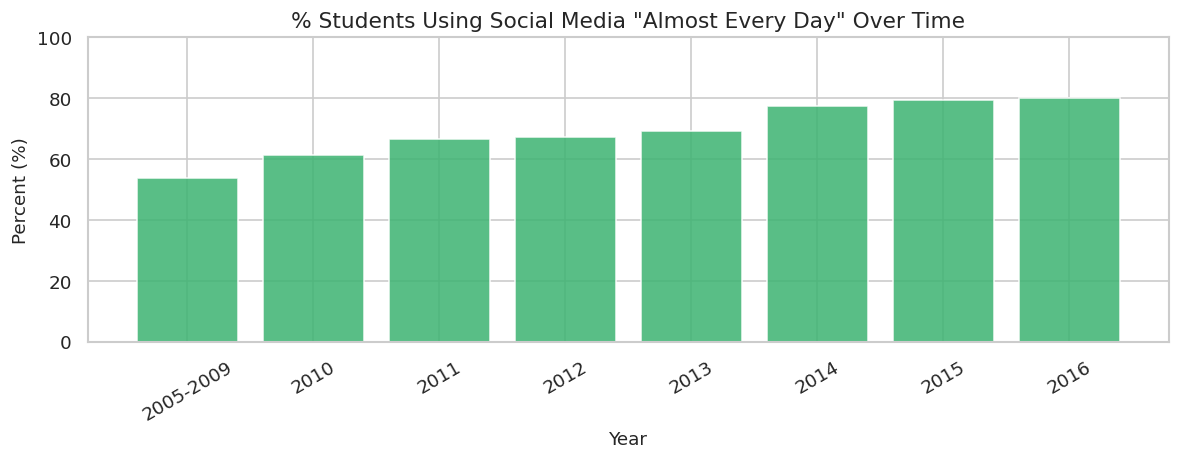

Social media use "almost every day" climbed from ~53.7% (2005-2009) to ~80% by 2016.


In [25]:
# Social Media Use Over Time
sm_pct = digital[digital['Subcategory'] == 'Social Media almost every day (%)'].copy()
sm_yr  = sm_pct.groupby('year')['value'].mean().reset_index()

print('=== Social Media "Almost Every Day" % by Year ===')
print(sm_yr.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(sm_yr['year'], sm_yr['value'], color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_title('% Students Using Social Media "Almost Every Day" Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Percent (%)')
ax.set_ylim(0, 100)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig_sm_pct_trend.png', bbox_inches='tight')
plt.show()
print('Social media use "almost every day" climbed from ~53.7% (2005-2009) to ~80% by 2016.')

=== Mean Media Use by Grade ===
grade                    8     10    12
Subcategory                            
Internet(hr/day)       1.33  1.49  1.66
Social Media (hr/day)  1.38  1.58  1.64
Texting (hr/day)       1.61  2.03  2.26


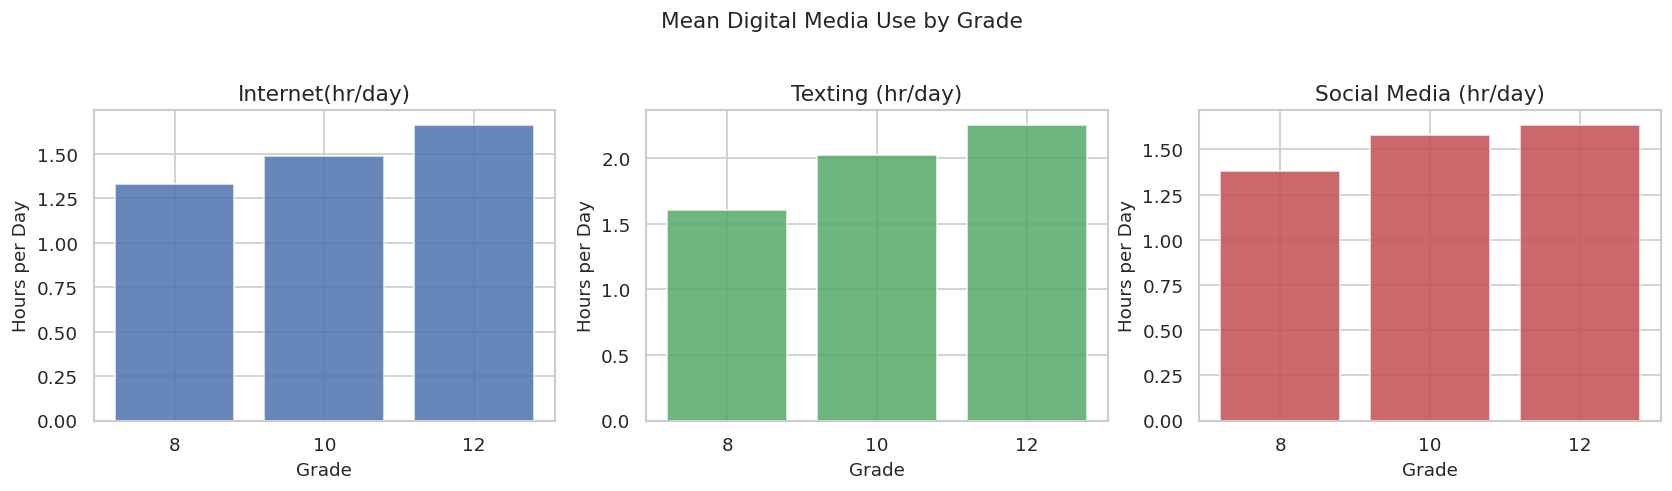

Older students consistently use digital media more across every category measured.


In [26]:
# Media Use (By Grade)
grade_subs = ['Internet(hr/day)', 'Texting (hr/day)', 'Social Media (hr/day)']
grade_df   = digital[digital['Subcategory'].isin(grade_subs)]
grade_means = grade_df.groupby(['Subcategory', 'grade'])['value'].mean().unstack('grade')

print('=== Mean Media Use by Grade ===')
print(grade_means.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
colors = ['#4C72B0', '#55A868', '#C44E52']
for ax, sub, color in zip(axes, grade_subs, colors):
    vals = grade_df[grade_df['Subcategory'] == sub].groupby('grade')['value'].mean()
    ax.bar(vals.index.astype(str), vals.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(sub)
    ax.set_xlabel('Grade')
    ax.set_ylabel('Hours per Day')

plt.suptitle('Mean Digital Media Use by Grade', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_media_by_grade.png', bbox_inches='tight')
plt.show()
print('Older students consistently use digital media more across every category measured.')

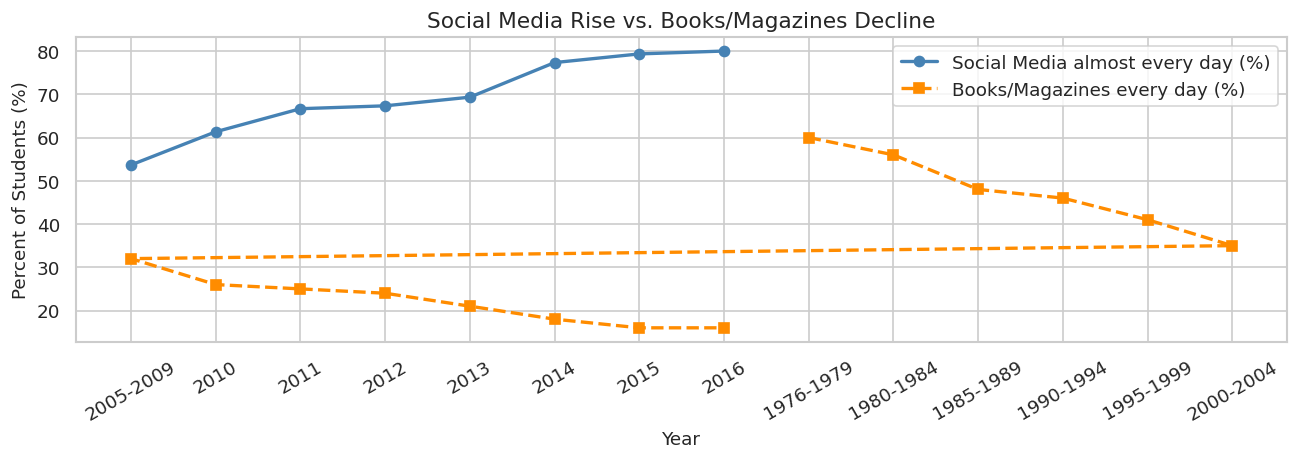

Books/magazines every day dropped from ~60% to ~16% — a near-mirror inverse of social media adoption.


In [27]:
# Legacy Media Use
legacy_books = media_all[
    (media_all['Subcategory'] == 'books/magazines every day (%)') &
    (media_all['value_mean_or_percent'] == 'percent')
].groupby('year')['value'].mean().reset_index()

sm_pct_all = digital[
    digital['Subcategory'] == 'Social Media almost every day (%)'
].groupby('year')['value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(sm_pct_all['year'], sm_pct_all['value'],
        marker='o', color='steelblue', linewidth=2, label='Social Media almost every day (%)')
ax.plot(legacy_books['year'], legacy_books['value'],
        marker='s', color='darkorange', linestyle='--', linewidth=2, label='Books/Magazines every day (%)')
ax.set_title('Social Media Rise vs. Books/Magazines Decline')
ax.set_xlabel('Year')
ax.set_ylabel('Percent of Students (%)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('fig_legacy_vs_digital.png', bbox_inches='tight')
plt.show()
print('Books/magazines every day dropped from ~60% to ~16% — a near-mirror inverse of social media adoption.')

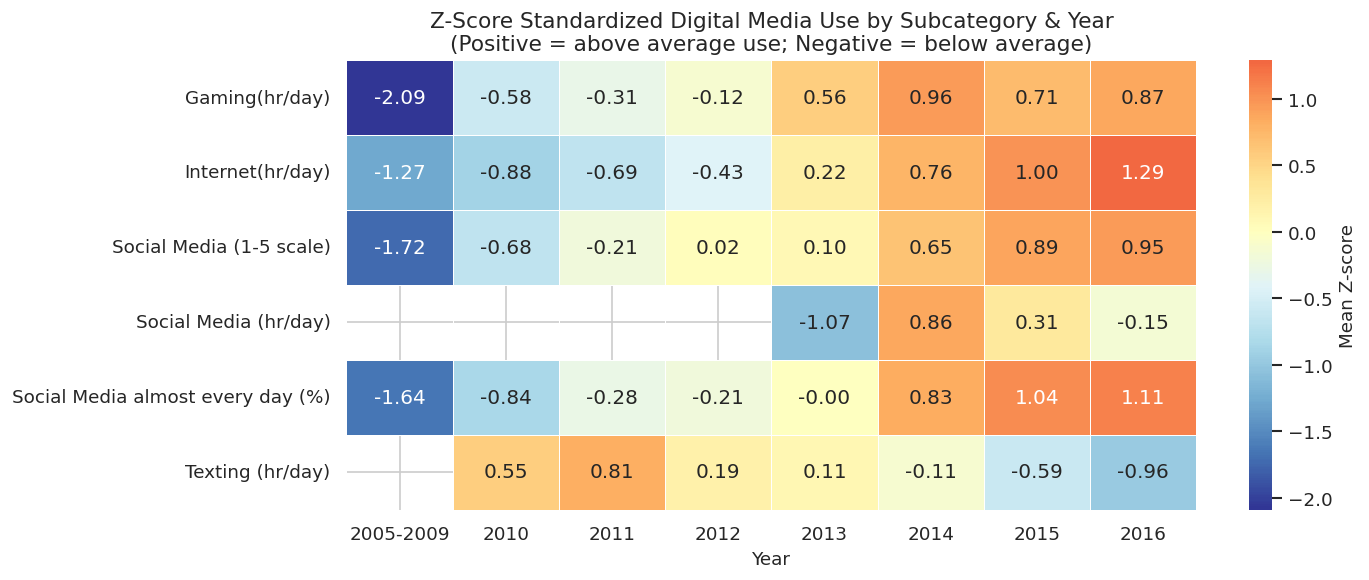

Recent years (2014-2016) show consistently high z-scores for social media and internet metrics.
Earlier years and gaming cluster near the mean.


In [28]:
# Z-Score Standardization by Subcategory
digital_z = digital.copy()
digital_z['z_value'] = digital_z.groupby('Subcategory')['value'].transform(
    lambda x: stats.zscore(x, nan_policy='omit')
)

# Heatmap: mean z-score by subcategory × year
z_pivot = digital_z.groupby(['Subcategory', 'year'])['z_value'].mean().unstack('year')

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(z_pivot, cmap='RdYlBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Mean Z-score'})
ax.set_title('Z-Score Standardized Digital Media Use by Subcategory & Year\n(Positive = above average use; Negative = below average)')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_zscore_heatmap.png', bbox_inches='tight')
plt.show()
print('Recent years (2014-2016) show consistently high z-scores for social media and internet metrics.')
print('Earlier years and gaming cluster near the mean.')



---

**Exploratory Analysis**

=== Top 10 States by Total Retained Students (Grades 8, 10, 12 | All Years) ===
         State  Total Retained Students
         Texas                 106220.0
      New York                  75258.0
       Florida                  75183.0
    California                  59789.0
       Georgia                  55940.0
      Illinois                  37362.0
  Pennsylvania                  32046.0
North Carolina                  29882.0
    Washington                  29557.0
      Maryland                  26353.0


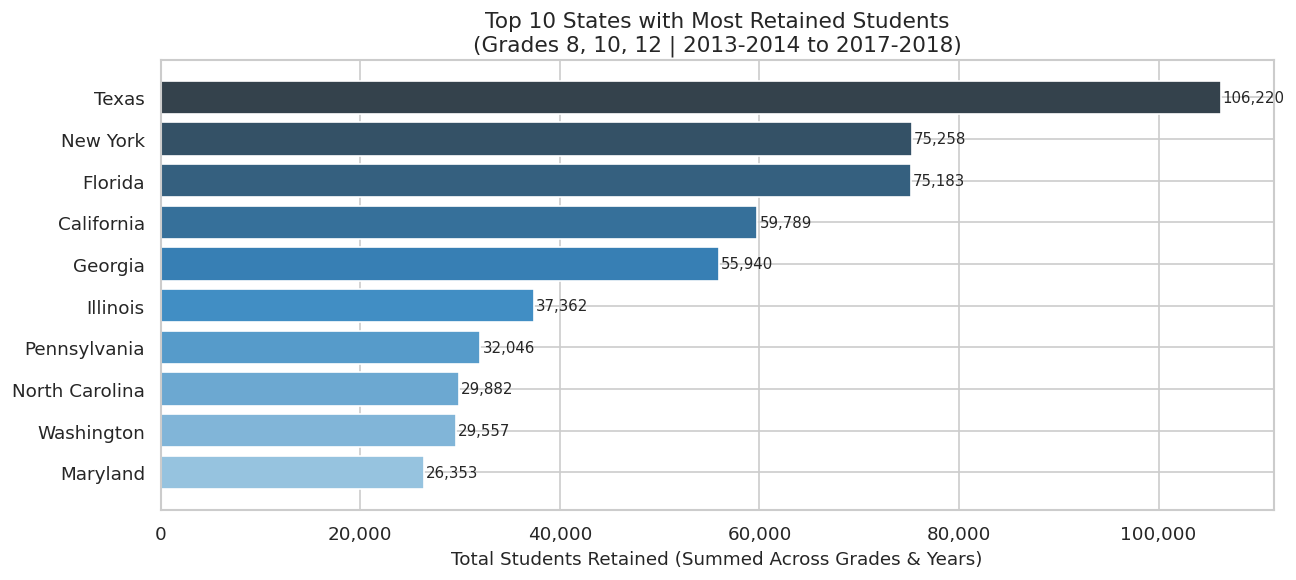


Note: Top states (TX, CA, FL) are expected given their large overall student populations.
Per-capita retention rates should be consulted for a fairer state-to-state comparison.


In [29]:
#Top 10 States with Most Retained Students
aggregate_labels = ['50 states, District of Columbia, and Puerto Rico']
ret_states = ret[~ret['State'].isin(aggregate_labels)]
state_totals = (
    ret_states.groupby('State')['Total Students']
       .sum()
       .sort_values(ascending=False)
       .head(10)
       .reset_index()
)
state_totals.columns = ['State', 'Total Retained Students']
print('=== Top 10 States by Total Retained Students (Grades 8, 10, 12 | All Years) ===')
print(state_totals.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
colors_top10 = sns.color_palette('Blues_d', 10)
bars = ax.barh(state_totals['State'][::-1], state_totals['Total Retained Students'][::-1],
               color=colors_top10, edgecolor='white')
ax.set_xlabel('Total Students Retained (Summed Across Grades & Years)')
ax.set_title('Top 10 States with Most Retained Students\n(Grades 8, 10, 12 | 2013-2014 to 2017-2018)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for bar, val in zip(bars, state_totals['Total Retained Students'][::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_top10_states.png', bbox_inches='tight')
plt.show()
print('\nNote: Top states (TX, CA, FL) are expected given their large overall student populations.')
print('Per-capita retention rates should be consulted for a fairer state-to-state comparison.')

In [31]:
# Per-enrollment Retention Rate

# Compute mean retention %
top10_states = state_totals['State'].tolist()
top10_data   = ret[ret['State'].isin(top10_states)]

pct_summary = top10_data.groupby('State')[['Percent_Male','Percent_Female','Percent_White',
                                            'Percent_Black or African American','Percent_Hispanic or Latino of any race','Percent_Students With Disabilities Served Under IDEA','Percent_English Language Learners']].mean().round(1)
pct_summary = pct_summary.loc[top10_states]  # keep ranked order
print('=== Mean Demographic % for Top 10 States ===')
print(pct_summary.to_string())

=== Mean Demographic % for Top 10 States ===
                Percent_Male  Percent_Female  Percent_White  Percent_Black or African American  Percent_Hispanic or Latino of any race  Percent_Students With Disabilities Served Under IDEA  Percent_English Language Learners
State                                                                                                                                                                                                                          
Texas                    0.6             0.4           19.7                               14.6                                    61.9                                                  21.7                               18.6
New York                 0.6             0.4           22.1                               31.9                                    37.8                                                  29.3                               17.2
Florida                  0.6             0.4           34.5

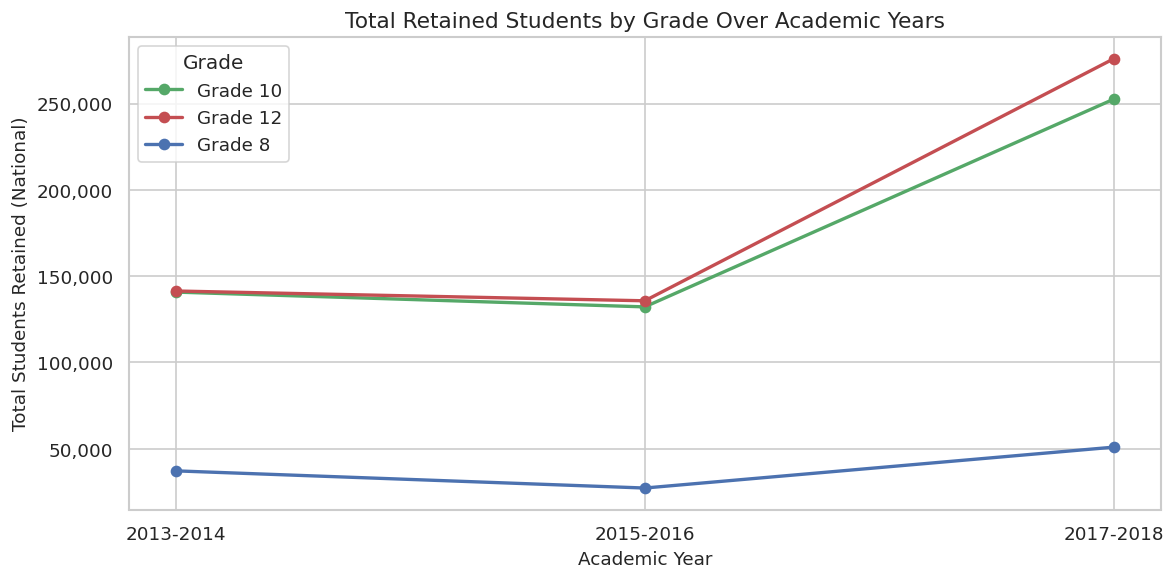

In [32]:
# Retention in 8th, 10th and 12th Over Time vs. Social Media Use
ret_yr_grade = (
    ret.groupby(['Academic Year', 'Grade'])['Total Students']
       .sum()
       .reset_index()
)
ret_yr_grade['Grade'] = ret_yr_grade['Grade'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
palette = {'8': '#4C72B0', '10': '#55A868', '12': '#C44E52'}
for grade, grp in ret_yr_grade.groupby('Grade'):
    ax.plot(grp['Academic Year'], grp['Total Students'],
            marker='o', linewidth=2, label=f'Grade {grade}', color=palette.get(grade, 'gray'))

ax.set_title('Total Retained Students by Grade Over Academic Years')
ax.set_xlabel('Academic Year')
ax.set_ylabel('Total Students Retained (National)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Grade')
plt.tight_layout()
plt.savefig('fig_retention_over_time.png', bbox_inches='tight')
plt.show()

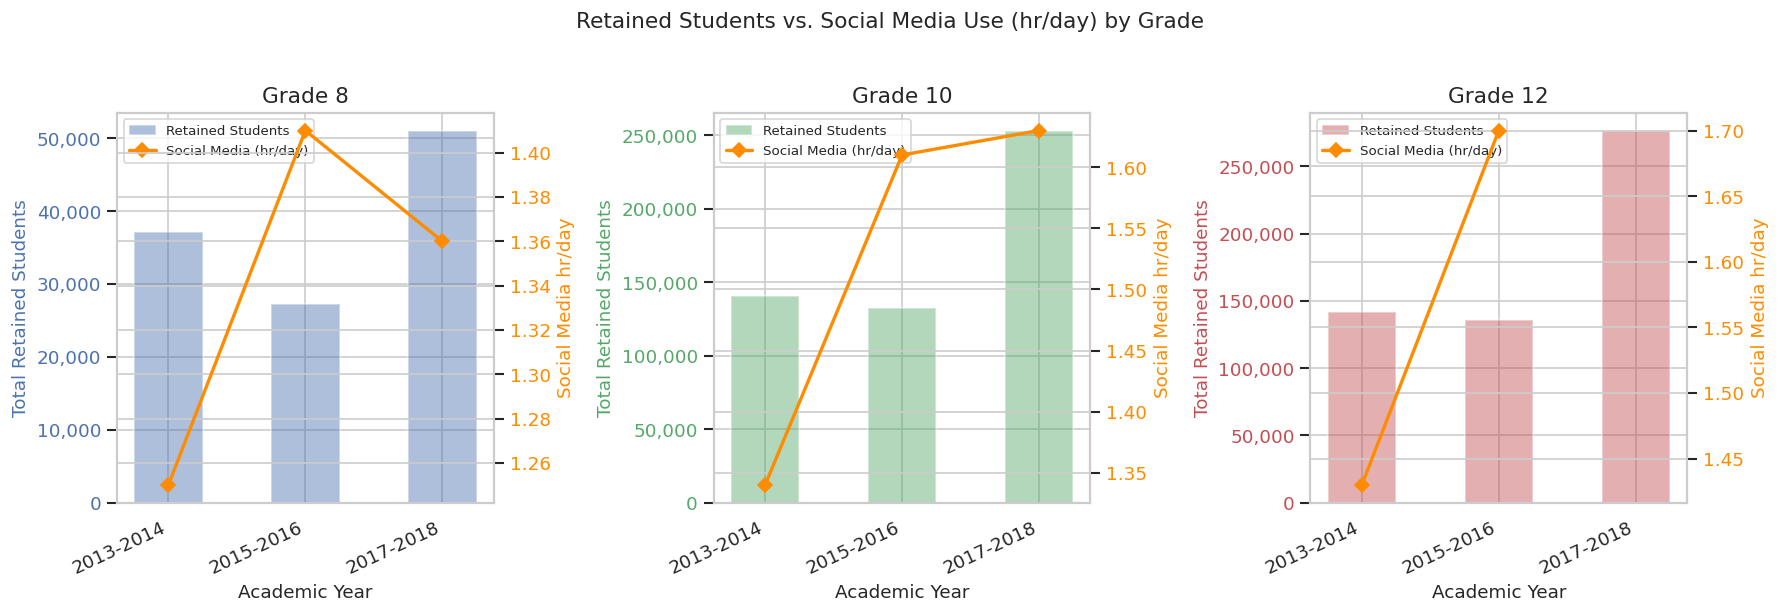

Note: Retention years mapped to closest media year (2013-2014→2013, 2015-2016→2015, 2017-2018→2016).


In [39]:
# Map Social Media Use of Overlapping Years
year_map = {'2013-2014': '2013', '2015-2016': '2015', '2017-2018': '2016'}
ret_mapped = ret_yr_grade.copy()
ret_mapped['media_year'] = ret_mapped['Academic Year'].map(year_map)

sm_hr = digital[digital['Subcategory'] == 'Social Media (hr/day)'].copy()
sm_grade_yr = sm_hr.groupby(['year', 'grade'])['value'].mean().reset_index()
sm_grade_yr['Grade'] = sm_grade_yr['grade'].astype(str)
sm_grade_yr = sm_grade_yr.rename(columns={'year': 'media_year'})

# Merge on media_year + Grade so x and y are always the same length
merged = ret_mapped.merge(
    sm_grade_yr[['media_year', 'Grade', 'value']],
    on=['media_year', 'Grade'],
    how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
grades = ['8', '10', '12']
colors_line = ['#4C72B0', '#55A868', '#C44E52']

for ax, grade, color in zip(axes, grades, colors_line):
    r_data = merged[merged['Grade'] == grade].sort_values('Academic Year')
    ax2 = ax.twinx()

    ax.bar(r_data['Academic Year'], r_data['Total Students'],
           color=color, alpha=0.45, label='Retained Students', width=0.5)
    ax.set_title(f'Grade {grade}')
    ax.set_xlabel('Academic Year')
    ax.set_ylabel('Total Retained Students', color=color)
    ax.tick_params(axis='y', labelcolor=color)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.setp(ax.get_xticklabels(), rotation=25, ha='right')

    ax2.plot(r_data['Academic Year'], r_data['value'],
             color='darkorange', marker='D', linewidth=2, label='Social Media (hr/day)')
    ax2.set_ylabel('Social Media hr/day', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

plt.suptitle('Retained Students vs. Social Media Use (hr/day) by Grade', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_retention_vs_sm.png', bbox_inches='tight')
plt.show()
print('Note: Retention years mapped to closest media year (2013-2014→2013, 2015-2016→2015, 2017-2018→2016).')

=== Total Retained Students by Race/Ethnicity (All States, Grades 8/10/12, All Years) ===
  White                          387,248
  Hispanic/Latino                383,158
  Black/African Am.              337,689
  Asian                           32,142
  Two or More Races               32,027
  Am. Indian/AK Native            16,500
  Native Hawaiian/PI               5,337


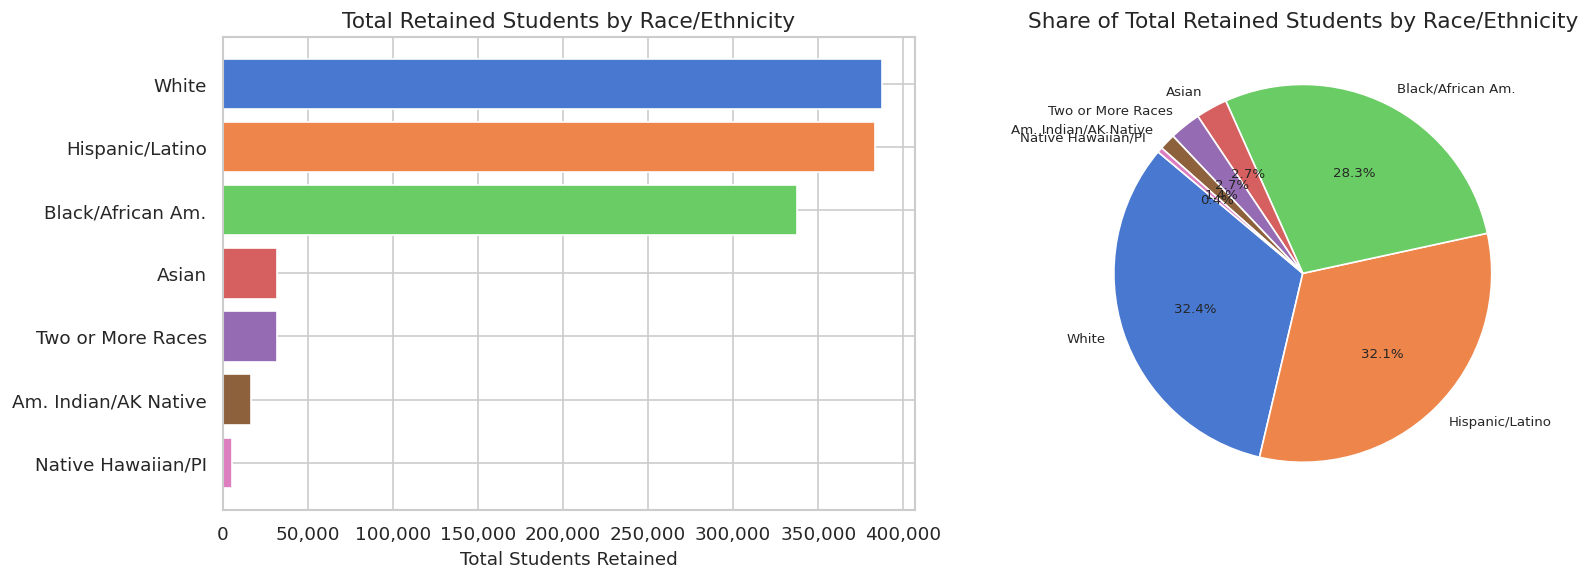

In [34]:
# Retention By Ethnicity
n_race_cols = ['Number_White', 'Number_Black or African American', 'Number_Hispanic or Latino of any race', 'Number_Asian', 'Number_American Indian or Alaska Native', 'Number_Native Hawaiian or Other Pacific Islander', 'Number_Two or more races']
race_name   = ['White', 'Black/African Am.', 'Hispanic/Latino', 'Asian',
               'Am. Indian/AK Native', 'Native Hawaiian/PI', 'Two or More Races']

race_totals = ret[n_race_cols].sum().values
race_ser = pd.Series(race_totals, index=race_name).sort_values(ascending=False)

print('=== Total Retained Students by Race/Ethnicity (All States, Grades 8/10/12, All Years) ===')
for name, val in race_ser.items():
    print(f'  {name:<25} {val:>12,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
palette_race = sns.color_palette('muted', len(race_ser))
axes[0].barh(race_ser.index[::-1], race_ser.values[::-1], color=palette_race[::-1], edgecolor='white')
axes[0].set_title('Total Retained Students by Race/Ethnicity')
axes[0].set_xlabel('Total Students Retained')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie chart
axes[1].pie(race_ser.values, labels=race_ser.index, autopct='%1.1f%%',
            colors=palette_race, startangle=140,
            textprops={'fontsize': 8})
axes[1].set_title('Share of Total Retained Students by Race/Ethnicity')

plt.tight_layout()
plt.savefig('fig_ethnicity_counts.png', bbox_inches='tight')
plt.show()

=== Mean Ethnic % of Retained Students by Grade ===
       White  Black/Afr. Am.  Hispanic/Latino  Asian
Grade                                               
10     39.74           25.26            23.39   1.97
12     46.22           22.72            20.80   3.07
8      45.65           23.58            18.51   1.75


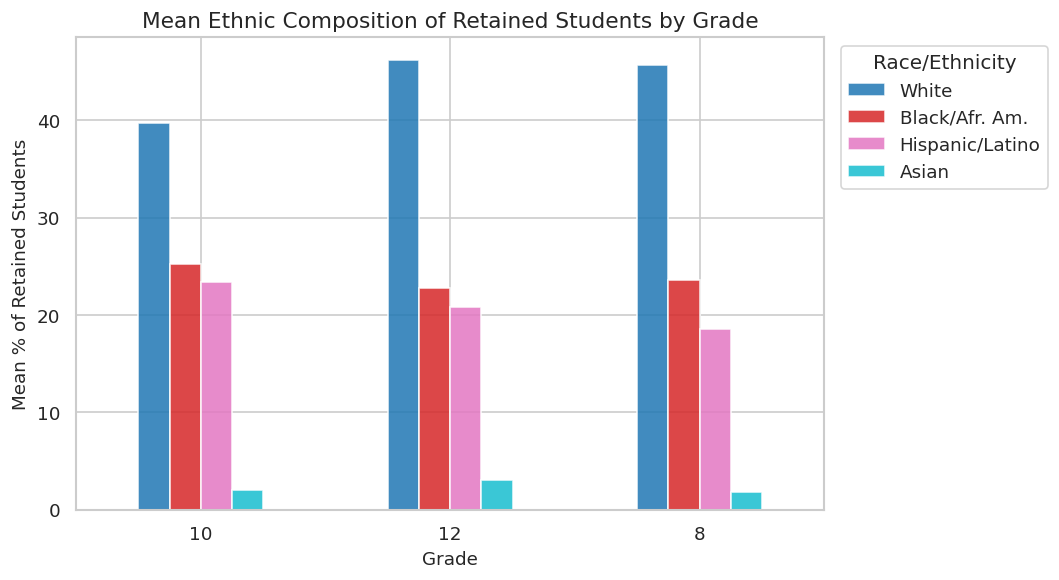

In [35]:
# Ethnicity Breakdown
pct_race = ['Percent_White', 'Percent_Black or African American', 'Percent_Hispanic or Latino of any race', 'Percent_Asian']
race_short = ['White', 'Black/Afr. Am.', 'Hispanic/Latino', 'Asian']

grade_race = ret.groupby('Grade')[pct_race].mean().rename(columns=dict(zip(pct_race, race_short)))
print('=== Mean Ethnic % of Retained Students by Grade ===')
print(grade_race.round(2).to_string())

grade_race.plot(kind='bar', figsize=(9, 5), colormap='tab10', edgecolor='white', alpha=0.85)
plt.title('Mean Ethnic Composition of Retained Students by Grade')
plt.xlabel('Grade')
plt.ylabel('Mean % of Retained Students')
plt.xticks(rotation=0)
plt.legend(title='Race/Ethnicity', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('fig_ethnicity_by_grade.png', bbox_inches='tight')
plt.show()

=== Mean Ethnic % of Retained Students by Academic Year ===
               White  Black/Afr. Am.  Hispanic/Latino  Asian
Academic Year                                               
2013-2014      44.84           24.89            19.05    2.4
2015-2016      44.57           23.33            20.63    2.1
2017-2018      42.27           23.37            22.95    2.3


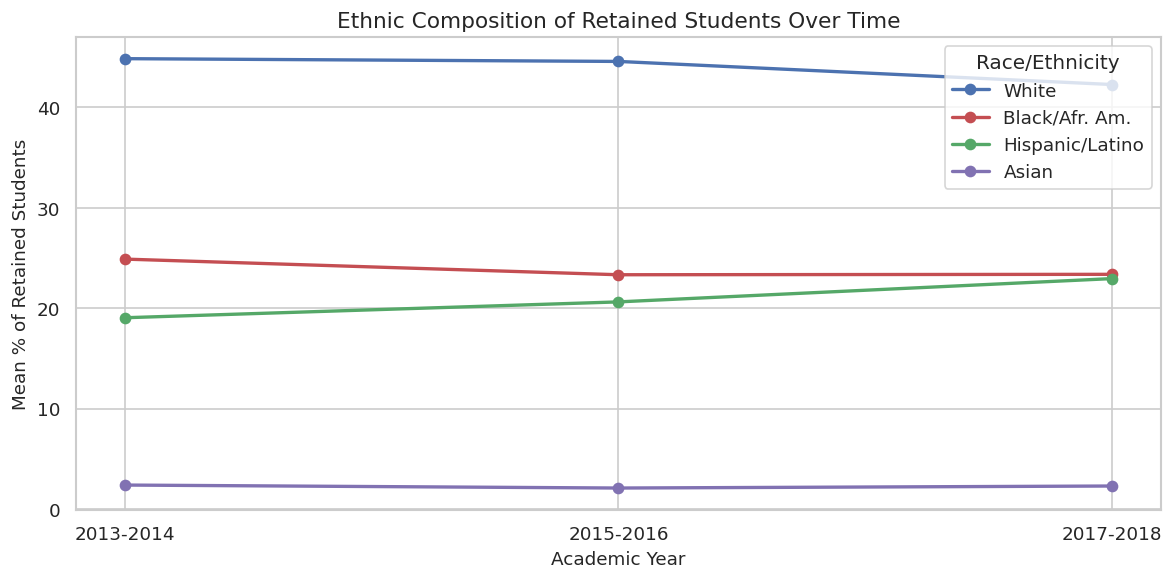

In [36]:
# Ethnicity Trend by Academic Year
year_race = ret.groupby('Academic Year')[pct_race].mean().rename(columns=dict(zip(pct_race, race_short)))
print('=== Mean Ethnic % of Retained Students by Academic Year ===')
print(year_race.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
palette_eth = ['#4C72B0', '#C44E52', '#55A868', '#8172B2']
for col, color in zip(race_short, palette_eth):
    ax.plot(year_race.index, year_race[col], marker='o', label=col, color=color, linewidth=2)

ax.set_title('Ethnic Composition of Retained Students Over Time')
ax.set_xlabel('Academic Year')
ax.set_ylabel('Mean % of Retained Students')
ax.legend(title='Race/Ethnicity')
plt.tight_layout()
plt.savefig('fig_ethnicity_over_time.png', bbox_inches='tight')
plt.show()

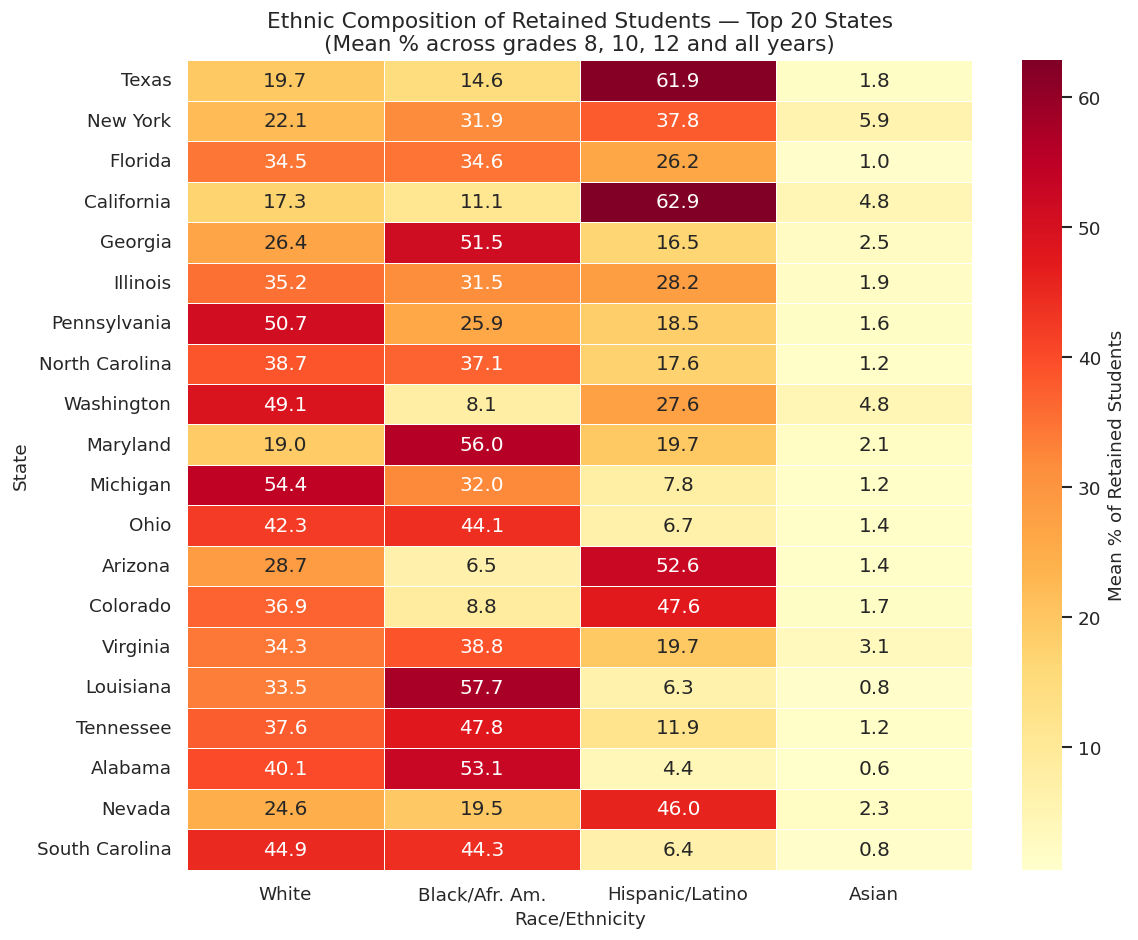

In [37]:
# Heatmap of Top 20 States by Total Retained
top20_states = (
    ret[~ret['State'].isin(['50 states, District of Columbia, and Puerto Rico'])].groupby('State')['Total Students'].sum()
       .sort_values(ascending=False)
       .head(20).index.tolist()
)
hm_data = (
    ret[~ret['State'].isin(['50 states, District of Columbia, and Puerto Rico']) & ret['State'].isin(top20_states)]
       .groupby('State')[pct_race]
       .mean()
       .rename(columns=dict(zip(pct_race, race_short)))
       .loc[top20_states]
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(hm_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.4,
            cbar_kws={'label': 'Mean % of Retained Students'}, ax=ax)
ax.set_title('Ethnic Composition of Retained Students — Top 20 States\n(Mean % across grades 8, 10, 12 and all years)')
ax.set_xlabel('Race/Ethnicity')
ax.set_ylabel('State')
plt.tight_layout()
plt.savefig('fig_state_ethnicity_heatmap.png', bbox_inches='tight')
plt.show()